In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Task 1

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].dt.to_timestamp()
monthly_sales = monthly_sales.sort_values(by='Month_Year')
monthly_sales.head()



,Month_Year,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


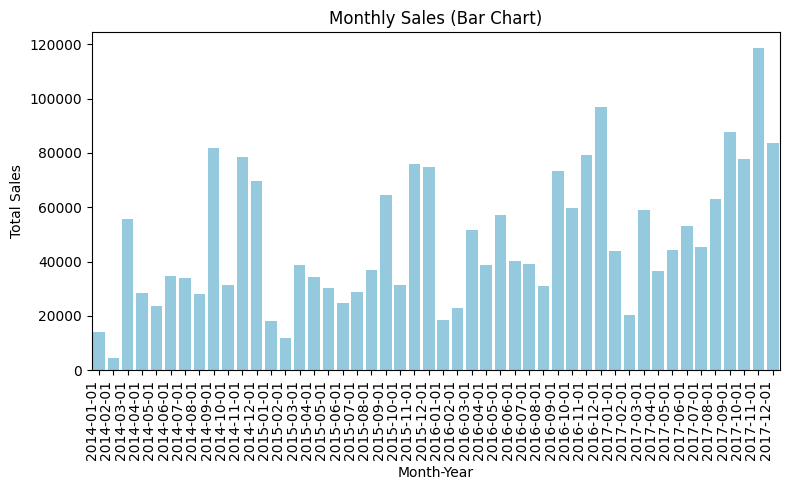

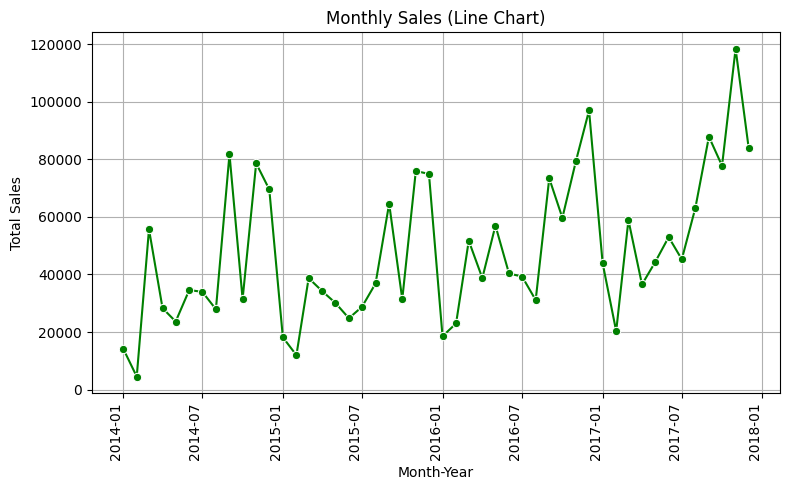

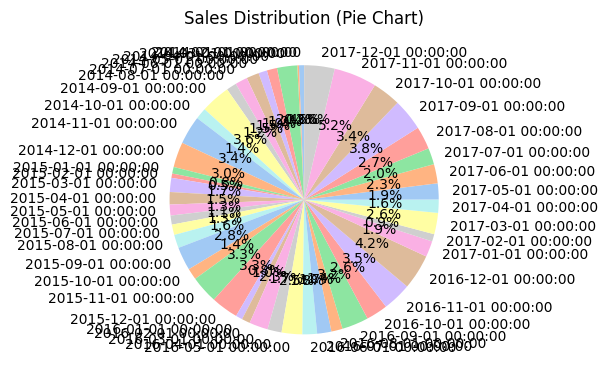

In [ ]:

# 1. Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Month_Year', y='Sales', data=monthly_sales, color='skyblue')
plt.title('Monthly Sales (Bar Chart)')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# 2. Line Chart
plt.figure(figsize=(8, 5))
sns.lineplot(x='Month_Year', y='Sales', data=monthly_sales, marker='o', color='green')
plt.title('Monthly Sales (Line Chart)')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=90, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(monthly_sales['Sales'], labels=monthly_sales['Month_Year'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sales Distribution (Pie Chart)')
plt.tight_layout()
plt.show()


The line chart shows it the best because the x values are more visible and gradual with the plotted line whereas in bar chart and pie chart, it is congested and difficult to recognise dates.

# Task 2

/tmp/ipykernel_18548/381487430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sub-Category', y='Sales', data=top_5_subcategories, palette='Accent')


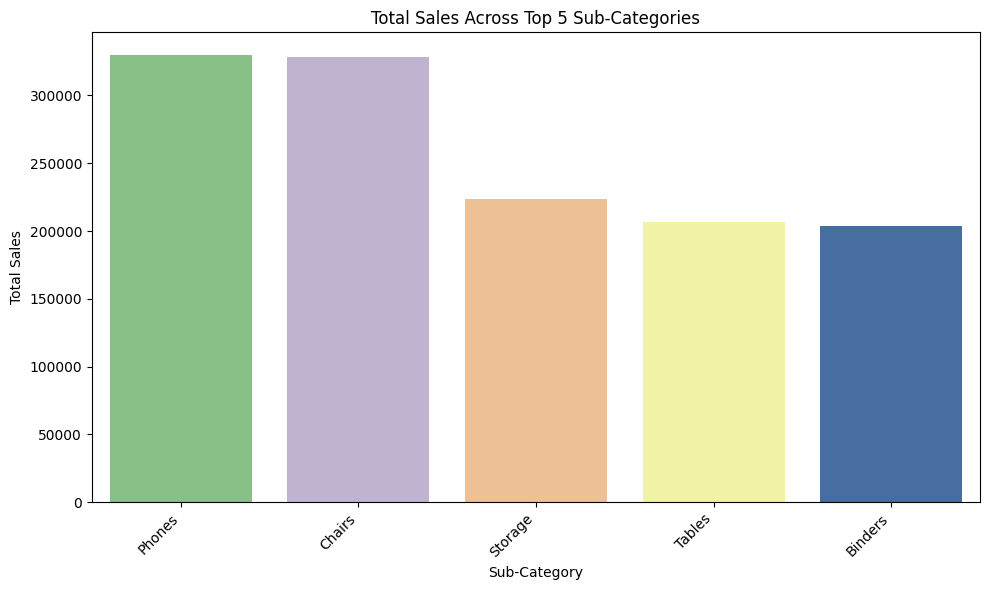

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_5_subcategories = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Sub-Category', y='Sales', data=top_5_subcategories, palette='Accent')
plt.title('Total Sales Across Top 5 Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Bar chart fits as it is a numerical and category scenerio, it is most visible.

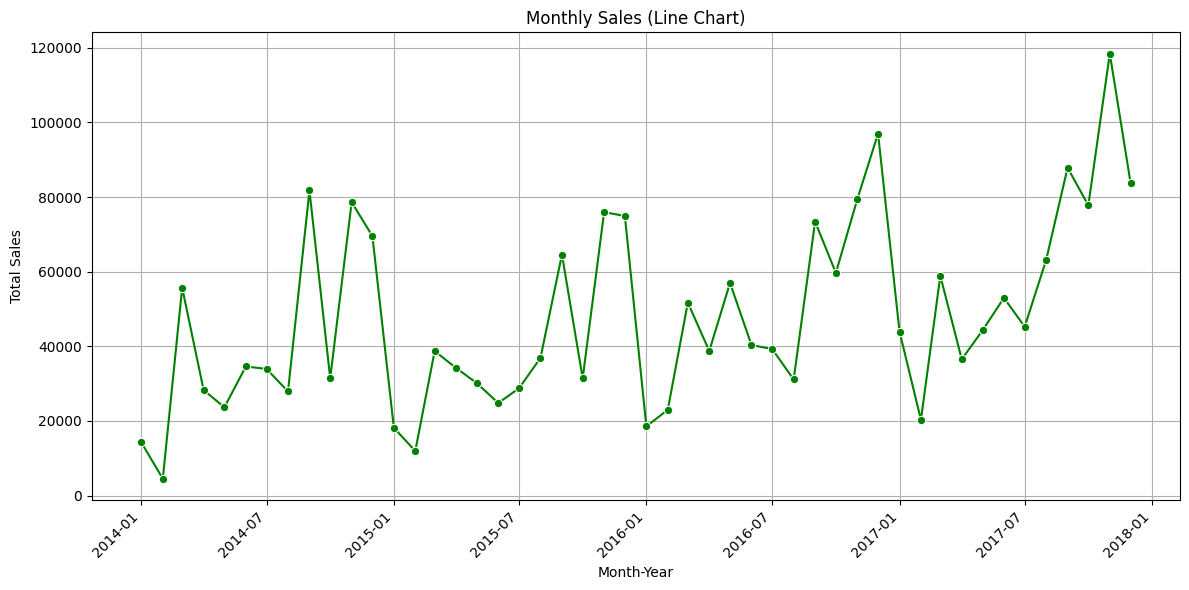

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_Year', y='Sales', data=monthly_sales, marker='o', color='green')
plt.title('Monthly Sales (Line Chart)')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

Line chart is best once again due to the clarity between dates and trend visulaisation showing steeps and drops.

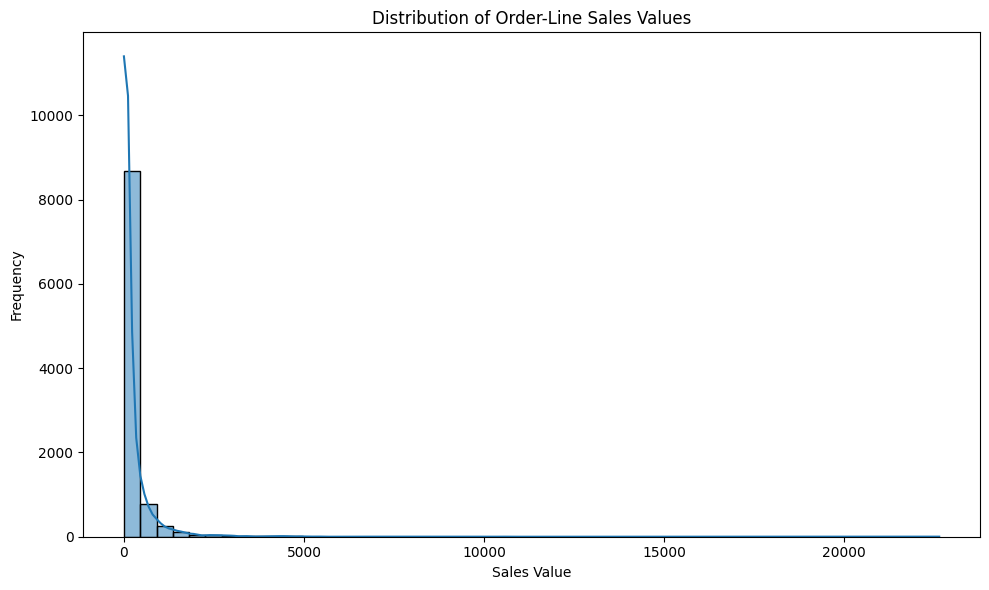

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, bins=50)
plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This graph shows it the best as the line and bars both demonstrate the trend average per bin

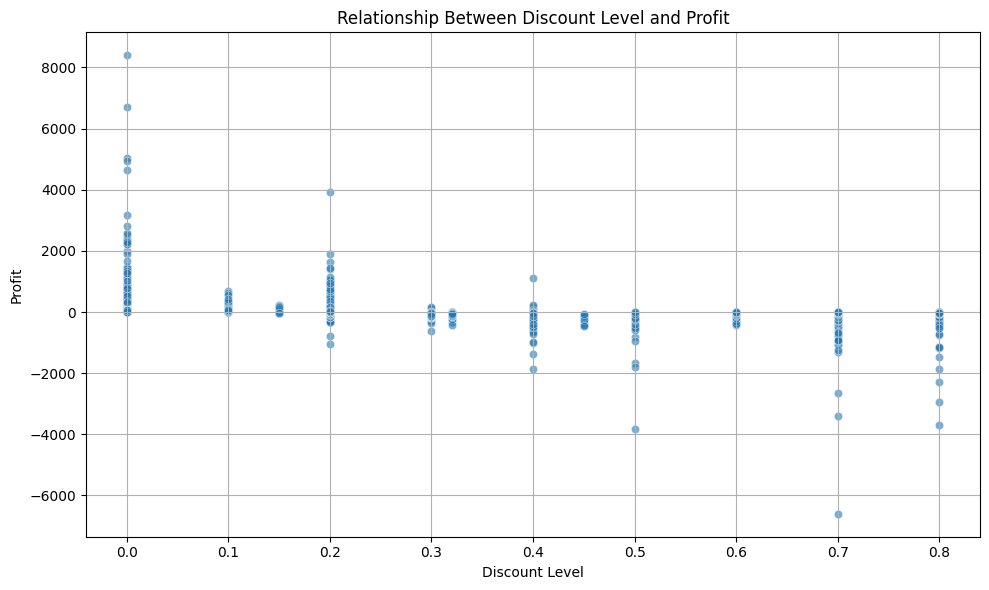

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Relationship Between Discount Level and Profit')
plt.xlabel('Discount Level')
plt.ylabel('Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

# Task 3

In [ ]:
region_sale = df.groupby('Region')['Sales'].sum()

/tmp/ipykernel_18548/2207447784.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sale.index, y=region_sale.values, palette='Set2')


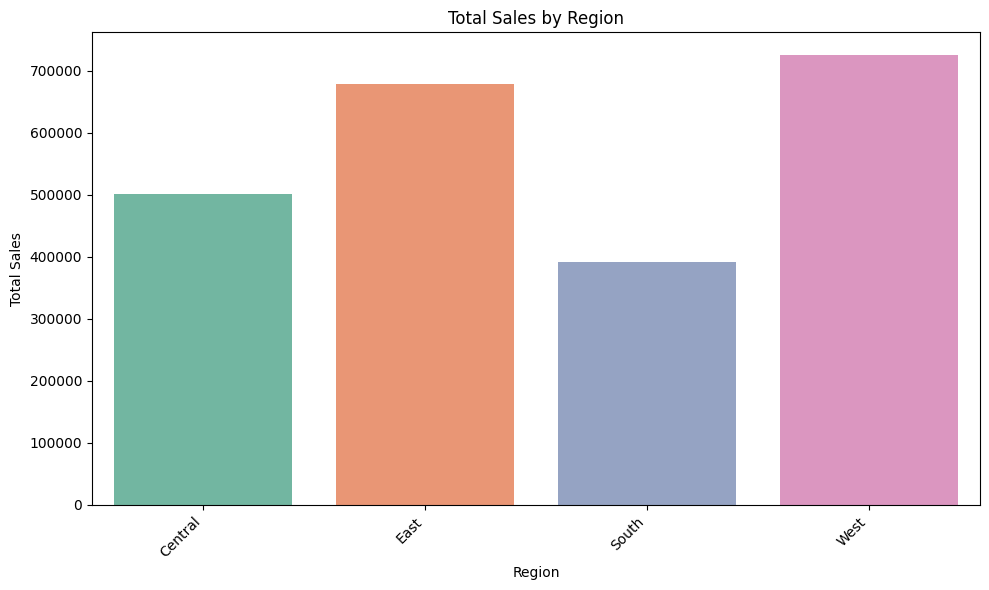

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=region_sale.index, y=region_sale.values, palette='Set2')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

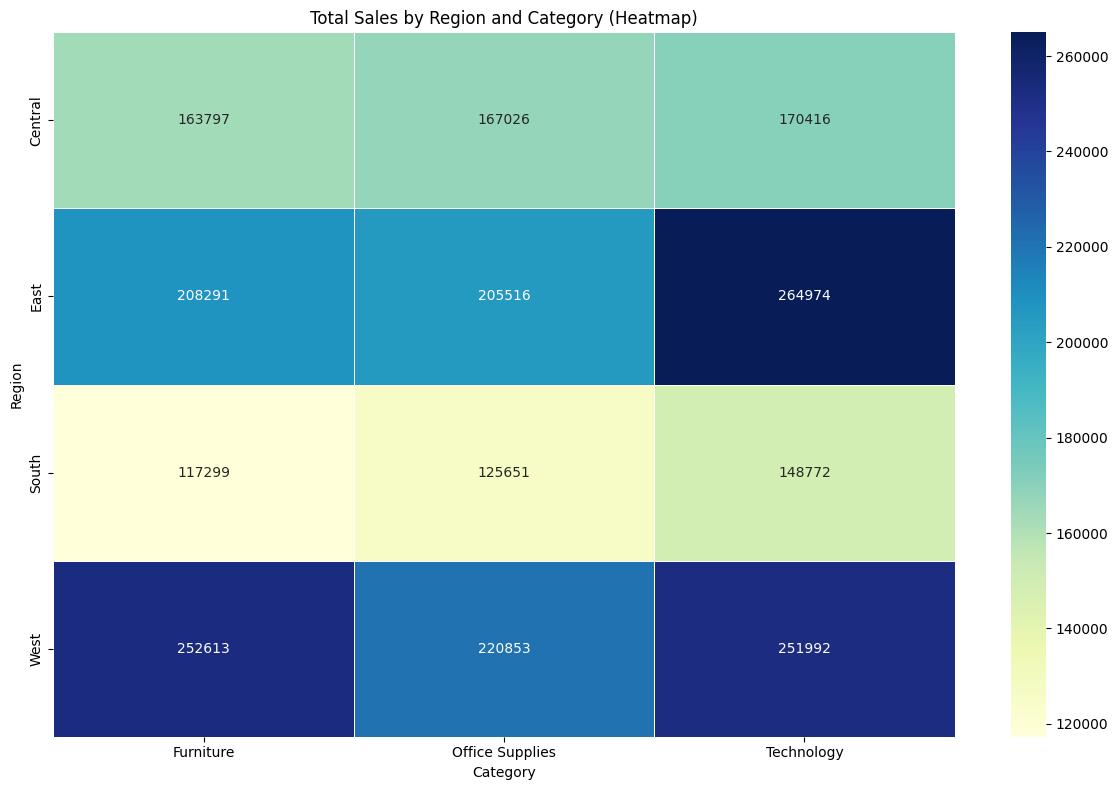

In [ ]:
# Prepare the data: Sales by Region and Category
region_category_sales = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(region_category_sales, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=.5)
plt.title('Total Sales by Region and Category (Heatmap)')
plt.xlabel('Category')
plt.ylabel('Region')
plt.tight_layout()
plt.show()



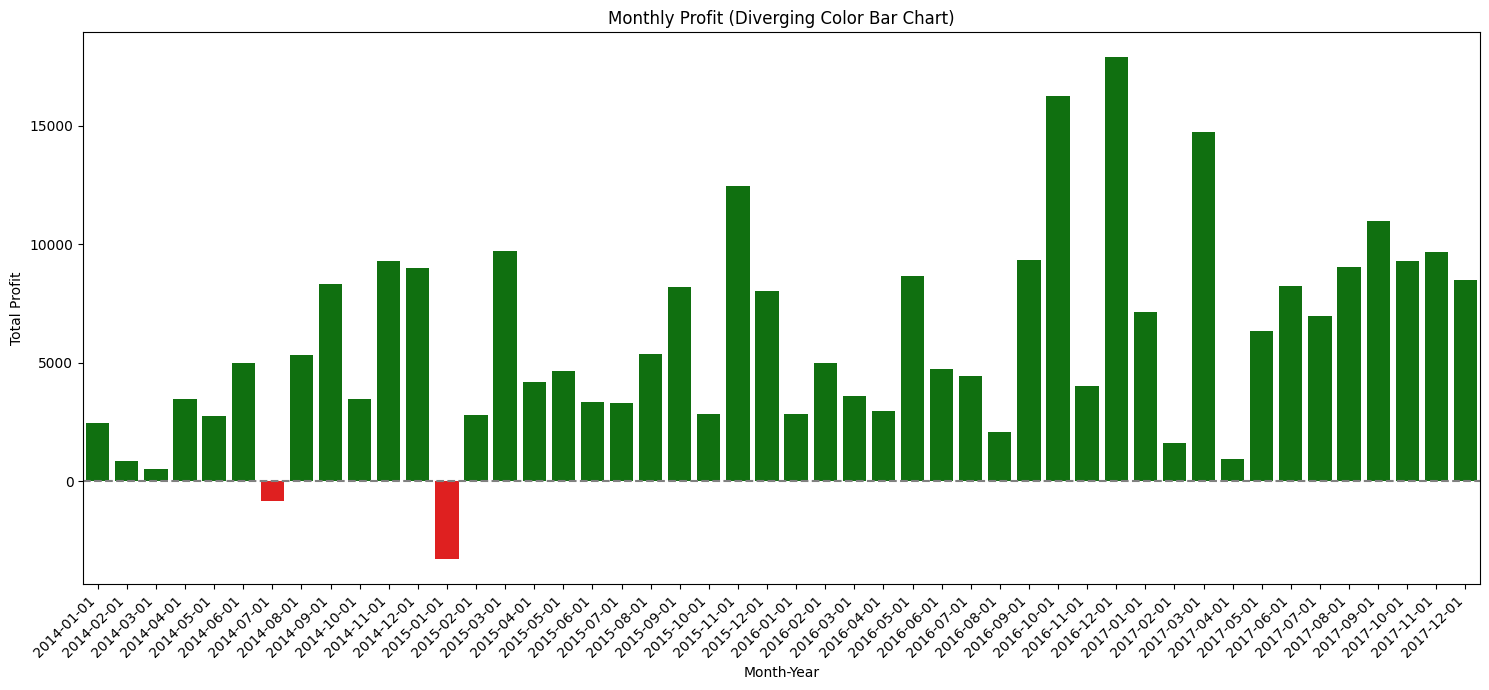

In [ ]:
# Prepare the data: Monthly Profit
# Ensure 'Order Date' is datetime and 'Month_Year' is created for consistency
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Year'] = df['Order Date'].dt.to_period('M')

monthly_profit = df.groupby('Month_Year')['Profit'].sum().reset_index()
monthly_profit['Month_Year'] = monthly_profit['Month_Year'].dt.to_timestamp()
monthly_profit = monthly_profit.sort_values(by='Month_Year')

plt.figure(figsize=(15, 7))
colors = ['red' if profit < 0 else 'green' for profit in monthly_profit['Profit']]
sns.barplot(x='Month_Year', y='Profit', data=monthly_profit, hue='Month_Year', palette=colors, legend=False)
plt.axhline(0, color='grey', linestyle='--', linewidth=1.5)
plt.title('Monthly Profit (Diverging Color Bar Chart)')
plt.xlabel('Month-Year')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task 4

In [ ]:
from matplotlib.colors import to_rgb, to_hex

# --- WCAG Contrast Ratio Function --- #
def sRGB_to_LinearRGB(c_srgb):
    """Converts a single sRGB component (0-1) to linear RGB."""
    if c_srgb <= 0.03928:
        return c_srgb / 12.92
    else:
        return ((c_srgb + 0.055) / 1.055) ** 2.4

def get_luminance(r, g, b):
    """Calculates relative luminance for an RGB color (0-255)."""
    r_linear = sRGB_to_LinearRGB(r / 255.0)
    g_linear = sRGB_to_LinearRGB(g / 255.0)
    b_linear = sRGB_to_LinearRGB(b / 255.0)
    return 0.2126 * r_linear + 0.7152 * g_linear + 0.0722 * b_linear

def get_contrast_ratio(rgb1, rgb2):
    """
    Computes the WCAG contrast ratio between two RGB colors (0-255 tuples).
    rgb1, rgb2: tuples (R, G, B) where R, G, B are integers from 0 to 255.
    """
    L1 = get_luminance(*rgb1)
    L2 = get_luminance(*rgb2)
    if L1 < L2:
        L1, L2 = L2, L1

    return (L1 + 0.05) / (L2 + 0.05)

print("--- WCAG Contrast Ratio Tests (AA threshold 4.5:1) ---")

white_rgb = (255, 255, 255)
black_rgb = (0, 0, 0)
AA_threshold = 4.5

# 1. Task 3(a): Region Sales Chart (palette='Set2' vs White background)
print("\n1. Region Sales Chart (Set2 palette vs White background):")
set2_palette = sns.color_palette('Set2')
for i, color_norm in enumerate(set2_palette):
    color_rgb = tuple(int(c * 255) for c in color_norm)
    cr = get_contrast_ratio(color_rgb, white_rgb)
    status = 'PASS' if cr >= AA_threshold else 'FAIL'
    print(f"  Color {i+1} {to_hex(color_norm)} (RGB: {color_rgb}): Ratio {cr:.2f}:1 ({status})")

# 2. Task 3(b): Heatmap (cmap='YlGnBu') - testing text on cell color
print("\n2. Heatmap (YlGnBu cmap with black text annotations):")
# Get representative colors from YlGnBu colormap
cmap = plt.colormaps['YlGnBu'] # Updated from plt.cm.get_cmap

# Test a light cell color against black text
light_cell_color_norm = cmap(0.1)
light_cell_color_rgb = tuple(int(c * 255) for c in light_cell_color_norm[:3])
cr_light_black = get_contrast_ratio(light_cell_color_rgb, black_rgb)
status_light = 'PASS' if cr_light_black >= AA_threshold else 'FAIL'
print(f"  Light Cell {to_hex(light_cell_color_norm[:3])} (RGB: {light_cell_color_rgb}) vs Black Text: Ratio {cr_light_black:.2f}:1 ({status_light})")

# Test a dark cell color against black text (likely to fail, white text is preferred)
dark_cell_color_norm = cmap(0.9)
dark_cell_color_rgb = tuple(int(c * 255) for c in dark_cell_color_norm[:3])
cr_dark_black = get_contrast_ratio(dark_cell_color_rgb, black_rgb)
cr_dark_white = get_contrast_ratio(dark_cell_color_rgb, white_rgb) # For comparison
status_dark = 'PASS' if cr_dark_black >= AA_threshold else 'FAIL'
print(f"  Dark Cell {to_hex(dark_cell_color_norm[:3])} (RGB: {dark_cell_color_rgb}) vs Black Text: Ratio {cr_dark_black:.2f}:1 ({status_dark}) (Often better with White Text: {cr_dark_white:.2f}:1)")

# 3. Task 3(c): Monthly Profit Chart (Red/Green vs White background)
print("\n3. Monthly Profit Chart (Standard Red/Green vs White background):")
red_name = 'red'
green_name = 'green'
red_rgb_0_255 = tuple(int(c * 255) for c in to_rgb(red_name))
green_rgb_0_255 = tuple(int(c * 255) for c in to_rgb(green_name))

cr_red_white = get_contrast_ratio(red_rgb_0_255, white_rgb)
cr_green_white = get_contrast_ratio(green_rgb_0_255, white_rgb)
status_red = 'PASS' if cr_red_white >= AA_threshold else 'FAIL'
status_green = 'PASS' if cr_green_white >= AA_threshold else 'FAIL'
print(f"  Red {to_hex(red_name)} (RGB: {red_rgb_0_255}) vs White Text/Background: Ratio {cr_red_white:.2f}:1 ({status_red})")
print(f"  Green {to_hex(green_name)} (RGB: {green_rgb_0_255}) vs White Text/Background: Ratio {cr_green_white:.2f}:1 ({status_green})")


--- WCAG Contrast Ratio Tests (AA threshold 4.5:1) ---

1. Region Sales Chart (Set2 palette vs White background):
  Color 1 #66c2a5 (RGB: (102, 194, 165)): Ratio 2.14:1 (FAIL)
  Color 2 #fc8d62 (RGB: (252, 141, 98)): Ratio 2.30:1 (FAIL)
  Color 3 #8da0cb (RGB: (141, 160, 203)): Ratio 2.62:1 (FAIL)
  Color 4 #e78ac3 (RGB: (231, 138, 195)): Ratio 2.38:1 (FAIL)
  Color 5 #a6d854 (RGB: (166, 216, 84)): Ratio 1.67:1 (FAIL)
  Color 6 #ffd92f (RGB: (255, 217, 47)): Ratio 1.38:1 (FAIL)
  Color 7 #e5c494 (RGB: (229, 196, 148)): Ratio 1.66:1 (FAIL)
  Color 8 #b3b3b3 (RGB: (179, 179, 179)): Ratio 2.10:1 (FAIL)

2. Heatmap (YlGnBu cmap with black text annotations):
  Light Cell #f1faba (RGB: (240, 249, 185)) vs Black Text: Ratio 18.96:1 (PASS)
  Dark Cell #1f2f87 (RGB: (30, 47, 135)) vs Black Text: Ratio 1.81:1 (FAIL) (Often better with White Text: 11.59:1)

3. Monthly Profit Chart (Standard Red/Green vs White background):
  Red #ff0000 (RGB: (255, 0, 0)) vs White Text/Background: Ratio 4.00:1 (FA


--- (b) Profit by Sub-Category Analysis ---


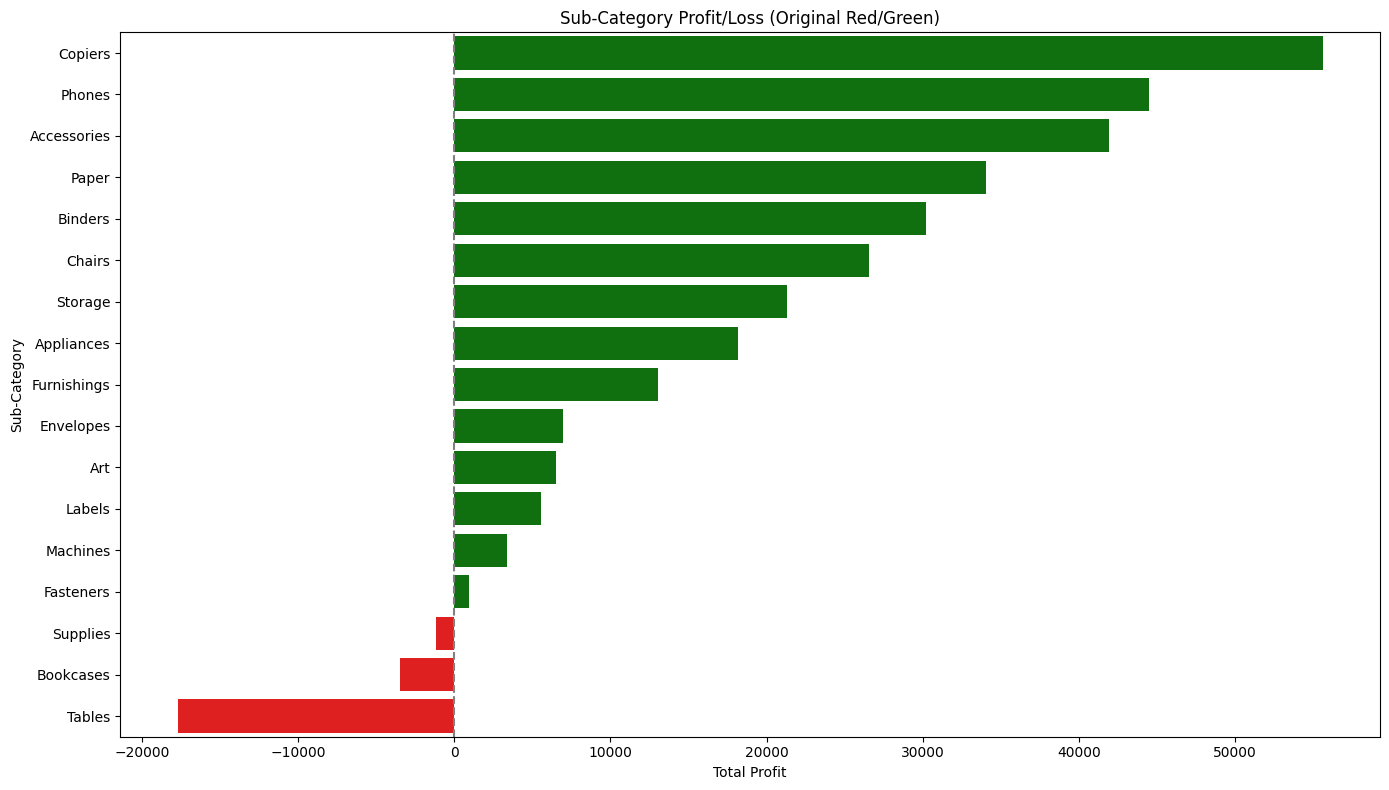

Saved 'subcategory_profit_original.png' for colorblind simulation.


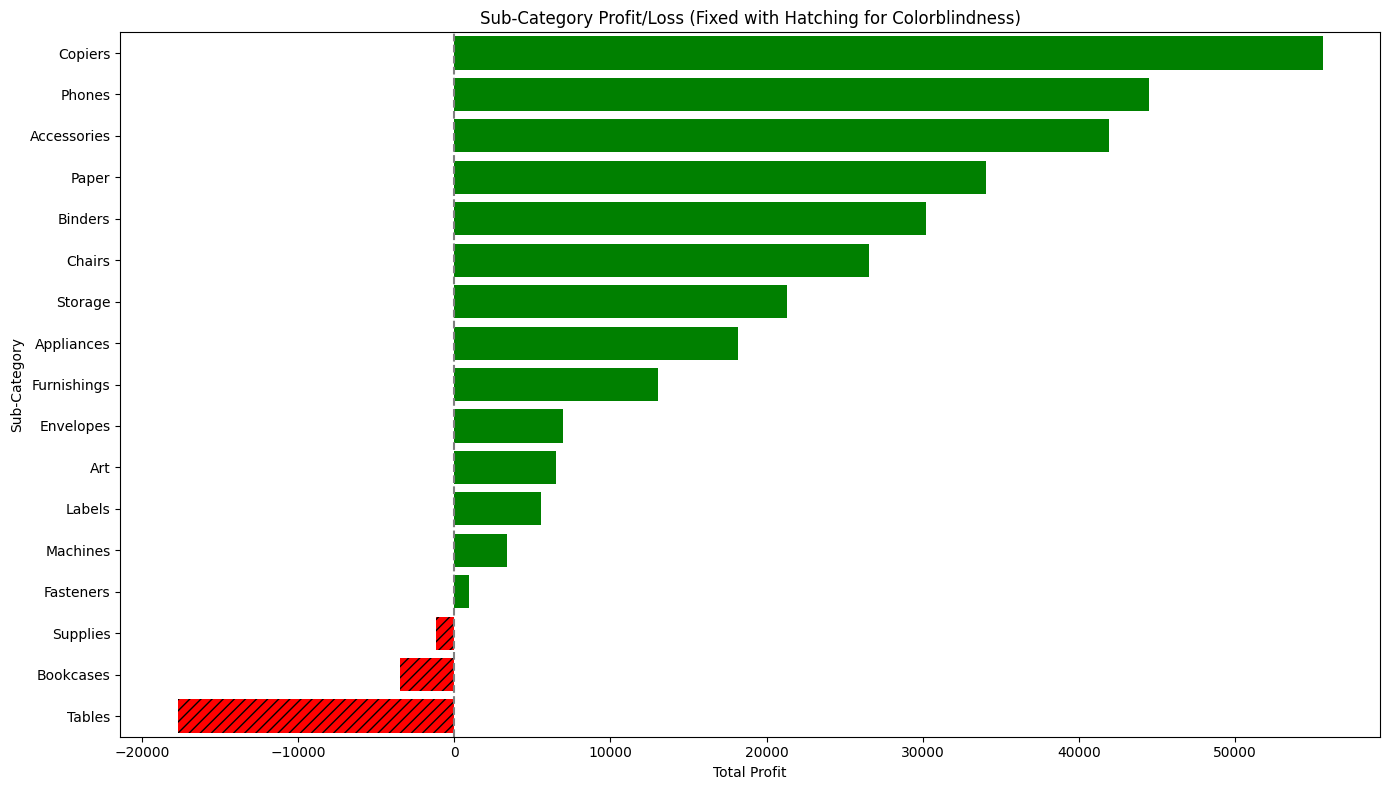

In [ ]:
print("\n--- (b) Profit by Sub-Category Analysis ---")

subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values(by='Profit', ascending=False)

# 1. Initial Chart: Red for Loss, Green for Gain
plt.figure(figsize=(14, 8))
colors_profit = ['red' if p < 0 else 'green' for p in subcategory_profit['Profit']]
sns.barplot(x='Profit', y='Sub-Category', data=subcategory_profit, palette=colors_profit, hue='Sub-Category', legend=False)
plt.title('Sub-Category Profit/Loss (Original Red/Green)')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.axvline(0, color='grey', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.savefig('subcategory_profit_original.png') # Save for simulation
plt.show()
print("Saved 'subcategory_profit_original.png' for colorblind simulation.")

# 2. Fixed Chart: Hatching for distinction, survives simulation
plt.figure(figsize=(14, 8))
bars = sns.barplot(x='Profit', y='Sub-Category', data=subcategory_profit, color='grey')
for i, p in enumerate(subcategory_profit['Profit']):
    if p < 0:
        bars.patches[i].set_facecolor('red')
        bars.patches[i].set_hatch('///')
    else:
        bars.patches[i].set_facecolor('green')

plt.title('Sub-Category Profit/Loss (Fixed with Hatching for Colorblindness)')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.axvline(0, color='grey', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()



Bar chart showing total profit by sub-category. Positive profit is indicated by green bars, while negative profit (loss) is indicated by red bars with diagonal hatching. The hatching provides a clear visual distinction for colorblind viewers.

# Task 5

/tmp/ipykernel_18548/3254584070.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_18548/3254584070.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_18548/3254584070.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')


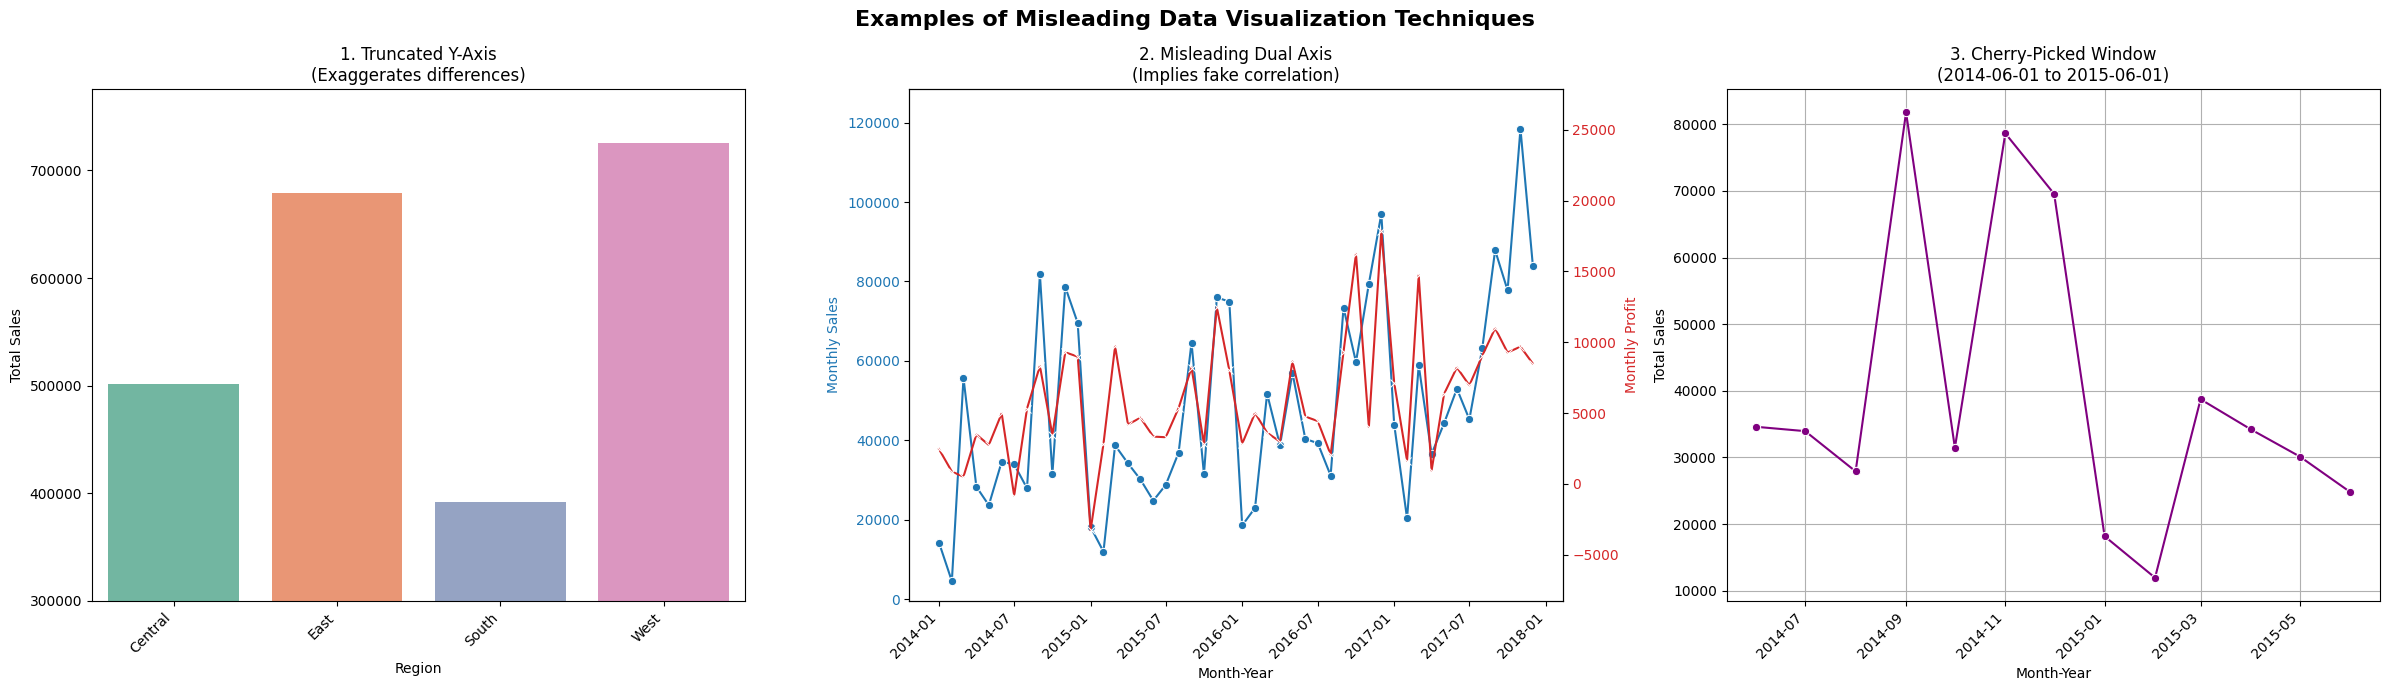

Plot 1: Truncated Y-axis minimizes baseline differences to make changes look huge.
Plot 2: Scaling two separate Y-axes forces a visual alignment that tricks the eye into seeing correlation.
Plot 3: Narrowing down dates hides long-term patterns, making a temporary shift look like a permanent trend.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

# Truncated Y-Axis
sns.barplot(x=region_sale.index, y=region_sale.values, palette='Set2', hue=region_sale.index, legend=False, ax=ax1)
ax1.set_ylim(300000, region_sale.values.max() + 50000)
ax1.set_title('1. Truncated Y-Axis\n(Exaggerates differences)')
ax1.set_xlabel('Region')
ax1.set_ylabel('Total Sales')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Misleading Dual Axis
color1, color2 = 'tab:blue', 'tab:red'
ax2.set_xlabel('Month-Year')
ax2.set_ylabel('Monthly Sales', color=color1)
sns.lineplot(x='Month_Year', y='Sales', data=monthly_sales, ax=ax2, color=color1, marker='o')
ax2.tick_params(axis='y', labelcolor=color1)
ax2.set_ylim(monthly_sales['Sales'].min() - 5000, monthly_sales['Sales'].max() + 10000)
ax2_twin = ax2.twinx()
ax2_twin.set_ylabel('Monthly Profit', color=color2)
sns.lineplot(x='Month_Year', y='Profit', data=monthly_profit, ax=ax2_twin, color=color2, marker='x')
ax2_twin.tick_params(axis='y', labelcolor=color2)
ax2_twin.set_ylim(monthly_profit['Profit'].min() - 5000, monthly_profit['Profit'].max() + 10000)
ax2.set_title('2. Misleading Dual Axis\n(Implies fake correlation)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

# Cherry-Picked Window
cp_start, cp_end = '2014-06-01', '2015-06-01'
cp_data = monthly_sales[(monthly_sales['Month_Year'] >= cp_start) & (monthly_sales['Month_Year'] <= cp_end)]
sns.lineplot(x='Month_Year', y='Sales', data=cp_data, marker='o', color='purple', ax=ax3)
ax3.set_title(f'3. Cherry-Picked Window\n({cp_start} to {cp_end})')
ax3.set_xlabel('Month-Year')
ax3.set_ylabel('Total Sales')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.grid(True)

# Main title and print cleanup
fig.suptitle('Examples of Misleading Data Visualization Techniques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Plot 1: Truncated Y-axis minimizes baseline differences to make changes look huge.")
print("Plot 2: Scaling two separate Y-axes forces a visual alignment that tricks the eye into seeing correlation.")
print("Plot 3: Narrowing down dates hides long-term patterns, making a temporary shift look like a permanent trend.")


# Task 6

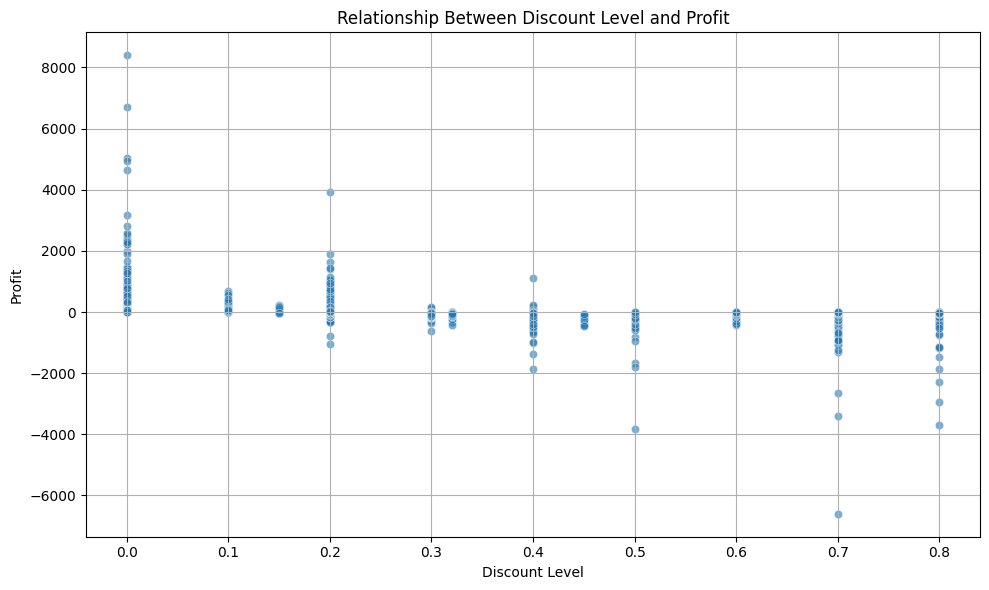

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Relationship Between Discount Level and Profit')
plt.xlabel('Discount Level')
plt.ylabel('Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

A misleading version of the question

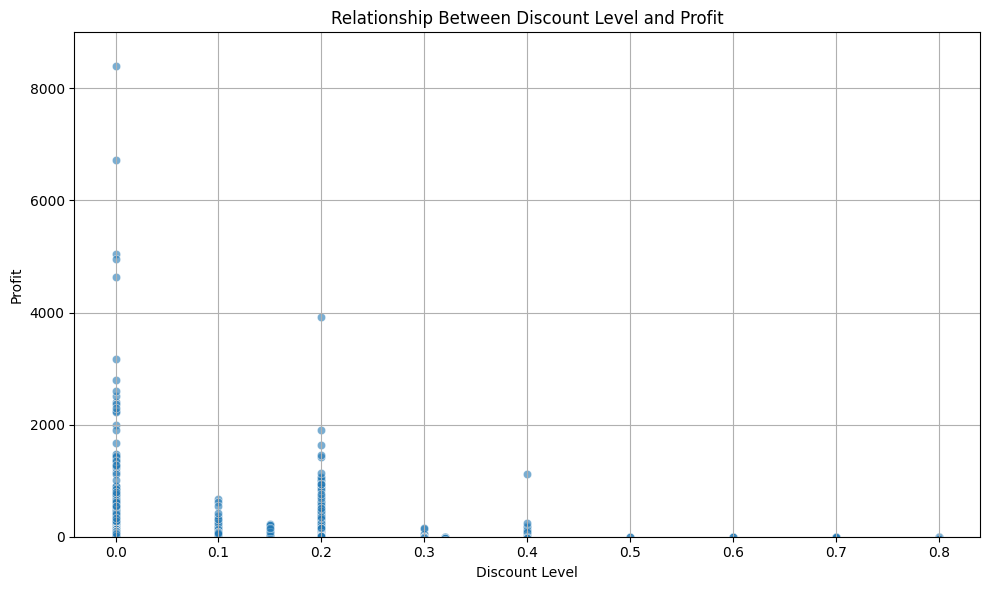

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.ylim(-1, 9000)
plt.title('Relationship Between Discount Level and Profit')
plt.xlabel('Discount Level')
plt.ylabel('Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

Chart type choice was scatter plot as each discount level has multiple profit values so to show all its the best. color choice was blue because all vales represent numerical values of one variable.